In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf

from scipy import signal
from IPython.display import Audio, display

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
import pandas as pd

RESULTS_CSV = "../results/metrics/evaluation_results.csv"

df = pd.read_csv(RESULTS_CSV)

print("Total evaluated samples:", len(df))
print()
print(df.head())

Total evaluated samples: 3000

   sample_id         system split language         mixture_type  \
0  IG_023003  Impulse Guard  test  unknown    two_normal_noises   
1  IG_023004  Impulse Guard  test  unknown         normal_noise   
2  IG_023005  Impulse Guard  test  unknown  normal_plus_impulse   
3  IG_023006  Impulse Guard  test  unknown         normal_noise   
4  IG_023007  Impulse Guard  test  unknown         normal_noise   

        noise_type   noise_category  is_impulsive  target_snr  actual_snr  \
0            drone            drone         False        -5.0   -5.011697   
1   non_stationary             wind         False         0.0    0.000000   
2  musan+impulsive  musan+impulsive          True        10.0         NaN   
3       stationary    engine_idling         False        15.0   15.000000   
4       stationary    engine_idling         False         5.0    5.000000   

   ... dnsmos_sig_noisy dnsmos_bak_noisy dnsmos_ovrl_noisy  \
0  ...         2.801780         2.700038 

In [4]:
noisy_df = df[df["noise_category"] != "clean"].copy()
clean_df = df[df["noise_category"] == "clean"].copy()

print("Total evaluated samples:", len(df))
print("Noisy samples:", len(noisy_df))
print("Clean control samples:", len(clean_df))

Total evaluated samples: 3000
Noisy samples: 2687
Clean control samples: 313


In [5]:
imp_samples = noisy_df[noisy_df["is_impulsive"] == True].copy()

print("Total impulsive samples:", len(imp_samples))

print(
    imp_samples[
        [
            "sample_id",
            "noise_category",
            "target_snr",
            "si_snr_improvement",
            "peak_attenuation_db_mean",
            "residual_energy_ratio_mean",
            "iisrt_mean_ms",
            "rsdd_mean_ms"
        ]
    ].head(30).to_string(index=False)
)

Total impulsive samples: 1695
sample_id                noise_category  target_snr  si_snr_improvement  peak_attenuation_db_mean  residual_energy_ratio_mean  iisrt_mean_ms  rsdd_mean_ms
IG_023005               musan+impulsive        10.0            7.479178                 13.943500                    0.007267            NaN           NaN
IG_023010         musan+siren+impulsive        20.0            6.258327                 10.035248                    0.031160          180.0           0.0
IG_023011                     impulsive         5.0            0.504027                  2.159757                    0.668804           60.0          20.0
IG_023012          musan+wind+impulsive        20.0            0.712214                  8.726188                    0.070558          870.0         340.0
IG_023016               musan+impulsive        -5.0            3.414474                  8.877949                    0.026154            NaN           NaN
IG_023017         musan+siren+impulsive 

In [6]:
snr_summary = (
    noisy_df
    .dropna(subset=["target_snr"])
    .groupby("target_snr")["si_snr_improvement"]
    .mean()
    .sort_index()
)

print(snr_summary)

target_snr
-5.0     5.297639
 0.0     5.673030
 5.0     5.221139
 10.0    5.228950
 15.0    3.959333
 20.0    2.905438
Name: si_snr_improvement, dtype: float64


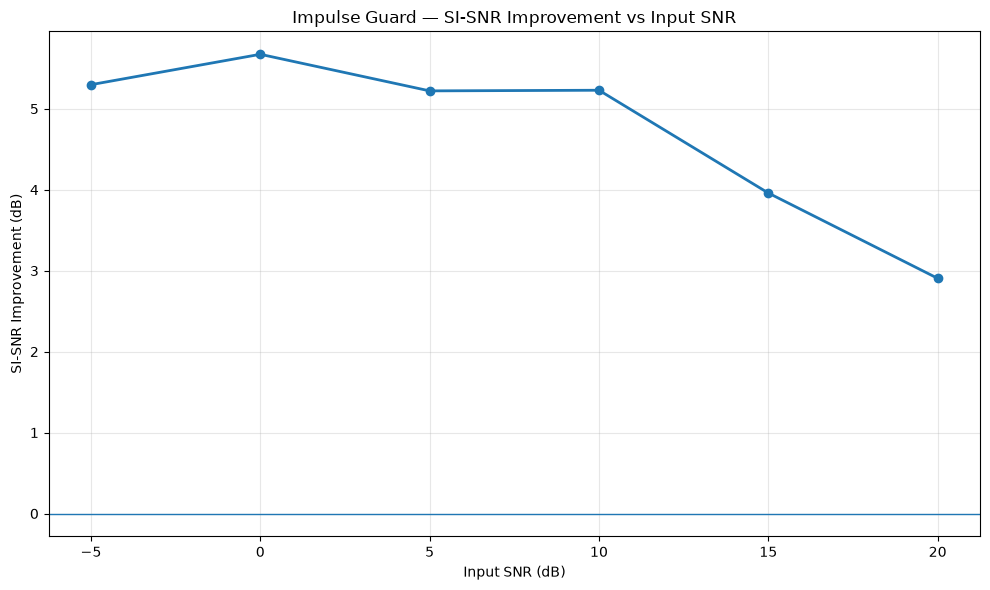

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    snr_summary.index,
    snr_summary.values,
    marker="o",
    linewidth=2
)

plt.axhline(0, linewidth=1)

plt.xlabel("Input SNR (dB)")
plt.ylabel("SI-SNR Improvement (dB)")
plt.title("Impulse Guard — SI-SNR Improvement vs Input SNR")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
non_impulsive = noisy_df[
    noisy_df["is_impulsive"] == False
]["si_snr_improvement"].mean()

impulsive = noisy_df[
    noisy_df["is_impulsive"] == True
]["si_snr_improvement"].mean()

print(f"Non-impulsive SI-SNR improvement: {non_impulsive:.2f} dB")
print(f"Impulsive SI-SNR improvement:     {impulsive:.2f} dB")

Non-impulsive SI-SNR improvement: 1.17 dB
Impulsive SI-SNR improvement:     6.76 dB


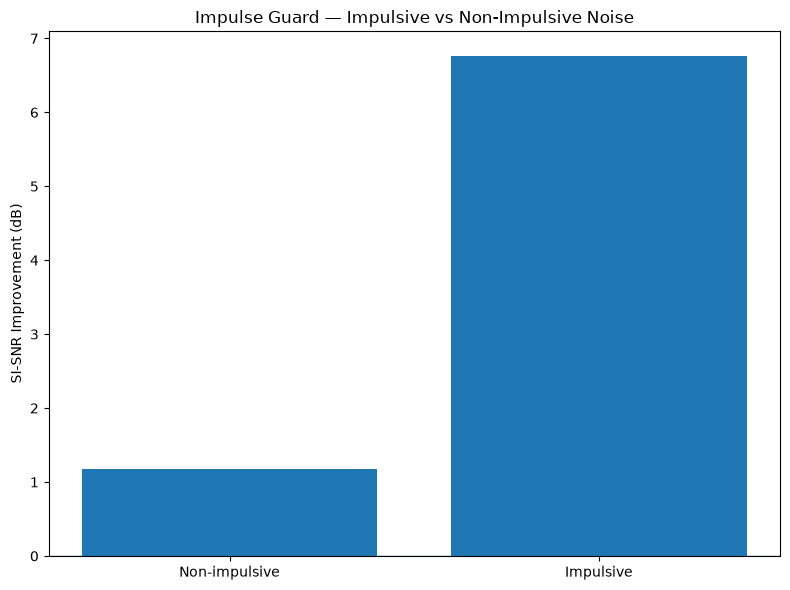

In [9]:
plt.figure(figsize=(8, 6))

plt.bar(
    ["Non-impulsive", "Impulsive"],
    [non_impulsive, impulsive]
)

plt.axhline(0, linewidth=1)

plt.ylabel("SI-SNR Improvement (dB)")
plt.title("Impulse Guard — Impulsive vs Non-Impulsive Noise")

plt.tight_layout()
plt.show()

In [10]:
imp_samples = noisy_df[noisy_df["is_impulsive"] == True].copy()

print("Total impulsive samples:", len(imp_samples))
print()

print(
    imp_samples[
        [
            "sample_id",
            "noise_category",
            "target_snr",
            "si_snr_improvement",
            "peak_attenuation_db_mean",
            "residual_energy_ratio_mean",
            "iisrt_mean_ms",
            "rsdd_mean_ms"
        ]
    ].head(20).to_string(index=False)
)

Total impulsive samples: 1695

sample_id                noise_category  target_snr  si_snr_improvement  peak_attenuation_db_mean  residual_energy_ratio_mean  iisrt_mean_ms  rsdd_mean_ms
IG_023005               musan+impulsive        10.0            7.479178                 13.943500                    0.007267            NaN           NaN
IG_023010         musan+siren+impulsive        20.0            6.258327                 10.035248                    0.031160          180.0           0.0
IG_023011                     impulsive         5.0            0.504027                  2.159757                    0.668804           60.0          20.0
IG_023012          musan+wind+impulsive        20.0            0.712214                  8.726188                    0.070558          870.0         340.0
IG_023016               musan+impulsive        -5.0            3.414474                  8.877949                    0.026154            NaN           NaN
IG_023017         musan+siren+impulsive

In [11]:
imp_samples = noisy_df[noisy_df["is_impulsive"] == True].copy()

impulse_summary = {
    "Peak attenuation (dB)": imp_samples["peak_attenuation_db_mean"].mean(),
    "Residual energy ratio": imp_samples["residual_energy_ratio_mean"].mean(),
    "IISRT (ms)": imp_samples["iisrt_mean_ms"].mean(),
    "RSDD (ms)": imp_samples["rsdd_mean_ms"].mean()
}

for name, value in impulse_summary.items():
    print(f"{name}: {value:.2f}")

Peak attenuation (dB): 12.13
Residual energy ratio: 0.10
IISRT (ms): 233.45
RSDD (ms): 457.08


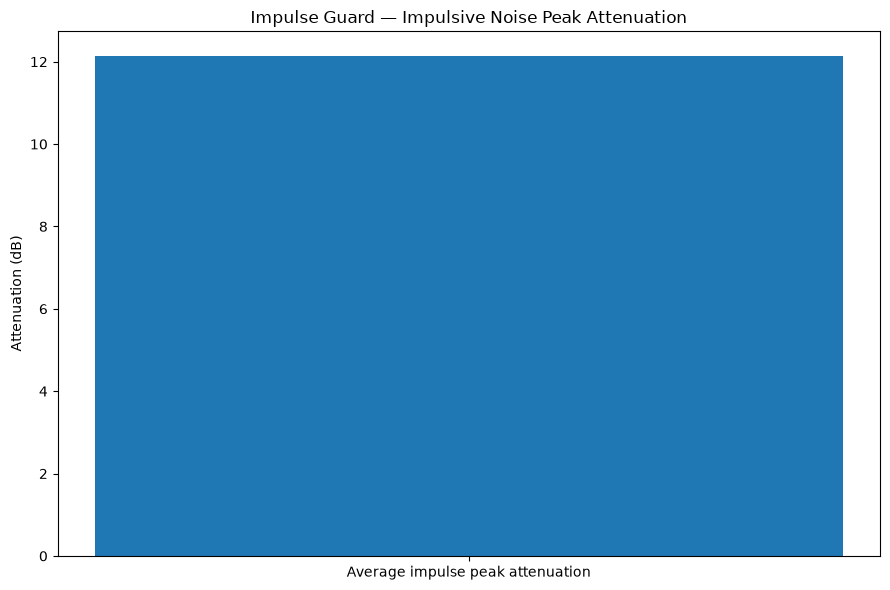

In [12]:
plt.figure(figsize=(9, 6))

plt.bar(
    ["Average impulse peak attenuation"],
    [imp_samples["peak_attenuation_db_mean"].mean()]
)

plt.ylabel("Attenuation (dB)")
plt.title("Impulse Guard — Impulsive Noise Peak Attenuation")

plt.tight_layout()
plt.show()

In [13]:
imp_samples = noisy_df[noisy_df["is_impulsive"] == True].copy()

# Sort by SI-SNR improvement so we can inspect strong examples first
best_impulsive = imp_samples.sort_values(
    "si_snr_improvement",
    ascending=False
)

print(
    best_impulsive[
        [
            "sample_id",
            "noise_category",
            "target_snr",
            "si_snr_improvement",
            "peak_attenuation_db_mean",
            "residual_energy_ratio_mean",
            "iisrt_mean_ms",
            "rsdd_mean_ms"
        ]
    ].head(10).to_string(index=False)
)

sample_id                noise_category  target_snr  si_snr_improvement  peak_attenuation_db_mean  residual_energy_ratio_mean  iisrt_mean_ms  rsdd_mean_ms
IG_023397               drone+impulsive        20.0           22.834204                 13.394514                    0.002705            NaN           NaN
IG_023088 engine_idling+siren+impulsive        15.0           21.154574                 10.923251                    0.009481          280.0         100.0
IG_025477               musan+impulsive        15.0           21.074687                 19.784149                    0.002457          140.0         410.0
IG_023103          musan+wind+impulsive        20.0           20.986500                 15.381813                    0.005830          650.0         160.0
IG_025047 drone+engine_idling+impulsive        15.0           20.051234                 15.216513                    0.006971          120.0          40.0
IG_023163                wind+impulsive         5.0           19.88069

In [14]:
# Select the best-performing impulsive test sample

imp_samples = noisy_df[noisy_df["is_impulsive"] == True].copy()

best_sample = imp_samples.sort_values(
    "si_snr_improvement",
    ascending=False
).iloc[0]

SAMPLE_ID = best_sample["sample_id"]

print("Selected sample:", SAMPLE_ID)
print("Noise condition:", best_sample["noise_category"])
print("Input SNR:", best_sample["target_snr"], "dB")
print("SI-SNR improvement:", round(best_sample["si_snr_improvement"], 2), "dB")
print("Peak attenuation:", round(best_sample["peak_attenuation_db_mean"], 2), "dB")
print("Residual energy ratio:", round(best_sample["residual_energy_ratio_mean"], 2))

Selected sample: IG_023397
Noise condition: drone+impulsive
Input SNR: 20.0 dB
SI-SNR improvement: 22.83 dB
Peak attenuation: 13.39 dB
Residual energy ratio: 0.0


In [16]:
import soundfile as sf
import numpy as np

noisy_path = f"../data/mixtures/test/noisy/{SAMPLE_ID}.wav"
clean_path = f"../data/mixtures/test/clean/{SAMPLE_ID}.wav"
enhanced_path = f"../data/enhanced/test/{SAMPLE_ID}.wav"

noisy, sr = sf.read(noisy_path, dtype="float32")
clean, _ = sf.read(clean_path, dtype="float32")
enhanced, _ = sf.read(enhanced_path, dtype="float32")

# Convert stereo to mono if necessary
if noisy.ndim > 1:
    noisy = noisy.mean(axis=1)

if clean.ndim > 1:
    clean = clean.mean(axis=1)

if enhanced.ndim > 1:
    enhanced = enhanced.mean(axis=1)

print("Sample:", SAMPLE_ID)
print("Sample rate:", sr)
print("Duration:", len(noisy) / sr, "seconds")
print("Noisy samples:", len(noisy))
print("Enhanced samples:", len(enhanced))
print("Clean samples:", len(clean))

Sample: IG_023397
Sample rate: 16000
Duration: 5.0 seconds
Noisy samples: 80000
Enhanced samples: 80000
Clean samples: 80000


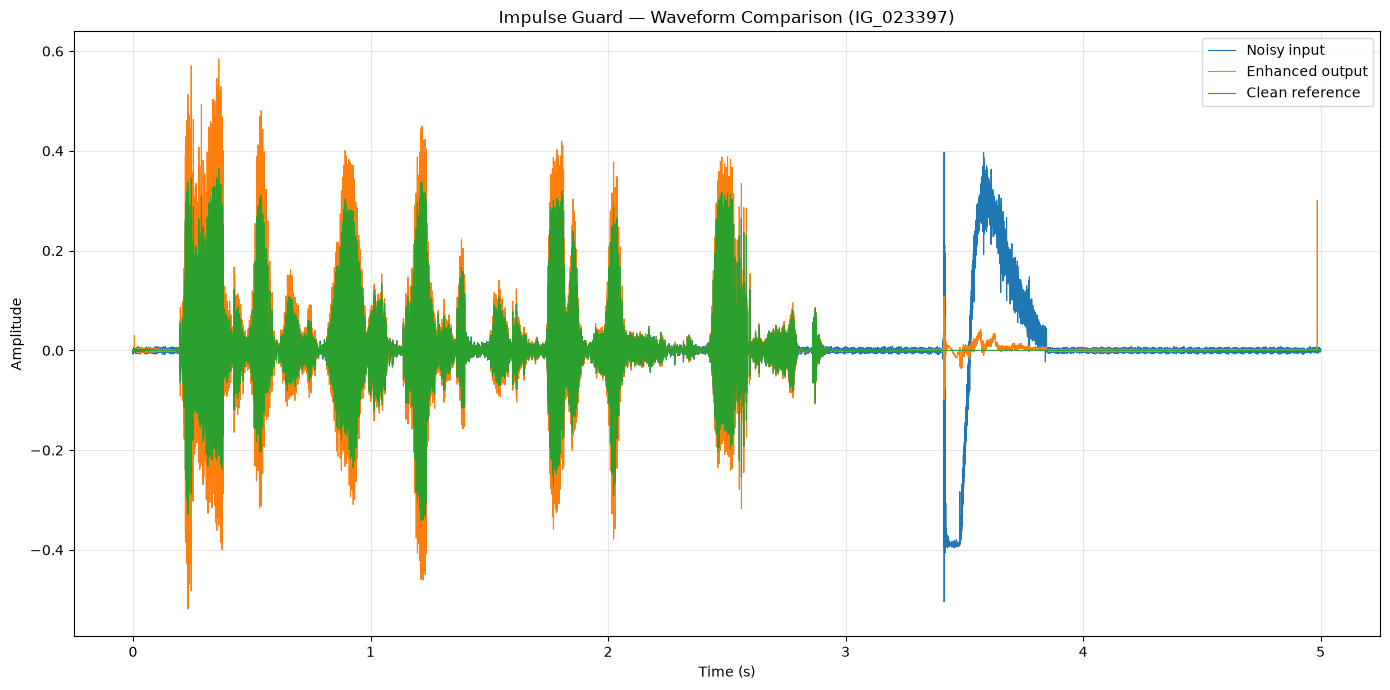

In [17]:
time = np.arange(len(noisy)) / sr

plt.figure(figsize=(14, 7))

plt.plot(time, noisy, label="Noisy input", linewidth=0.8)
plt.plot(time, enhanced, label="Enhanced output", linewidth=0.8)
plt.plot(time, clean, label="Clean reference", linewidth=0.8)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Impulse Guard — Waveform Comparison ({SAMPLE_ID})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [18]:
# Find the region containing the strongest transient in the noisy signal

window_ms = 20
window = int(sr * window_ms / 1000)

energy = np.convolve(
    noisy ** 2,
    np.ones(window) / window,
    mode="same"
)

impulse_center = np.argmax(energy)

impulse_time = impulse_center / sr

print("Strongest transient at:", round(impulse_time, 3), "seconds")

Strongest transient at: 3.447 seconds


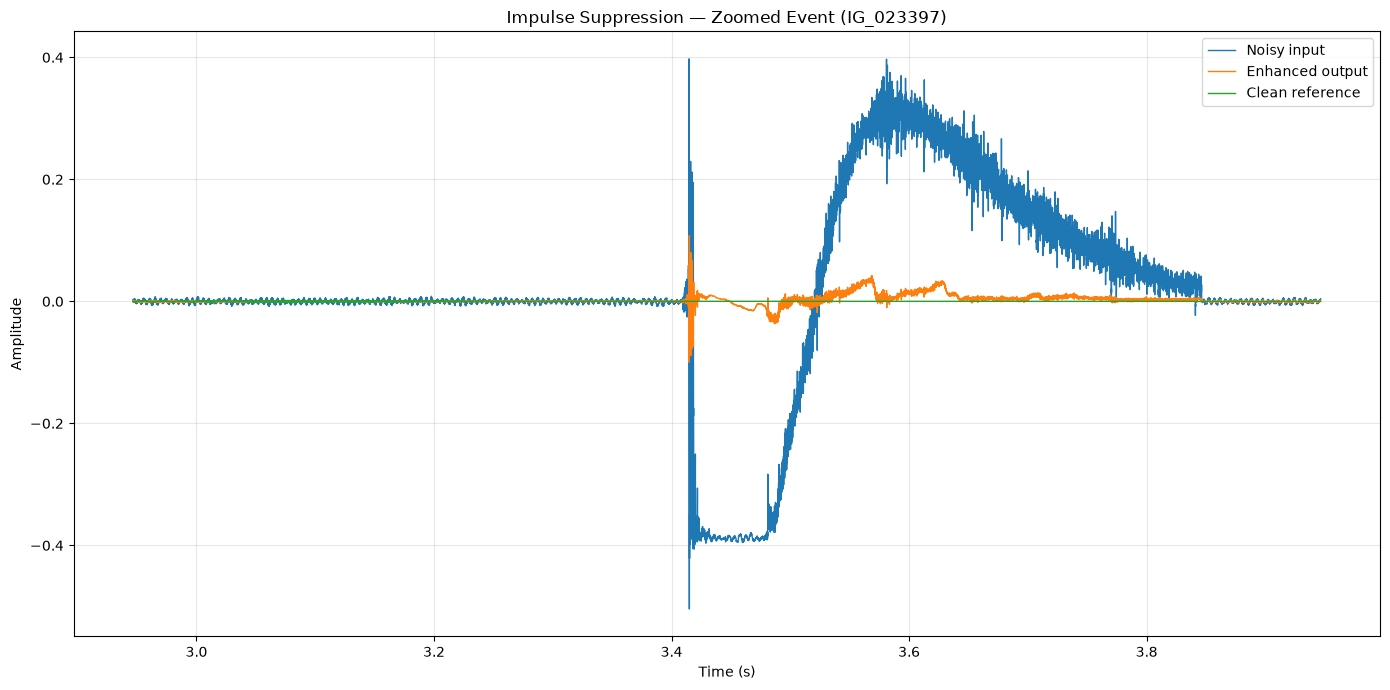

In [19]:
zoom_seconds = 0.5

start = max(0, impulse_center - int(zoom_seconds * sr))
end = min(len(noisy), impulse_center + int(zoom_seconds * sr))

zoom_time = np.arange(start, end) / sr

plt.figure(figsize=(14, 7))

plt.plot(
    zoom_time,
    noisy[start:end],
    label="Noisy input",
    linewidth=1
)

plt.plot(
    zoom_time,
    enhanced[start:end],
    label="Enhanced output",
    linewidth=1
)

plt.plot(
    zoom_time,
    clean[start:end],
    label="Clean reference",
    linewidth=1
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Impulse Suppression — Zoomed Event ({SAMPLE_ID})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [21]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

def plot_spectrogram(audio, sr, title):
    frequencies, times, Sxx = signal.stft(
        audio,
        fs=sr,
        nperseg=320,
        noverlap=160,
        nfft=512,
        boundary=None,
        padded=False
    )

    magnitude_db = 20 * np.log10(np.abs(Sxx) + 1e-8)

    plt.figure(figsize=(12, 6))

    plt.pcolormesh(
        times,
        frequencies,
        magnitude_db,
        shading="auto"
    )

    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(title)

    plt.ylim(0, 8000)

    plt.colorbar(label="Magnitude (dB)")
    plt.tight_layout()
    plt.show()

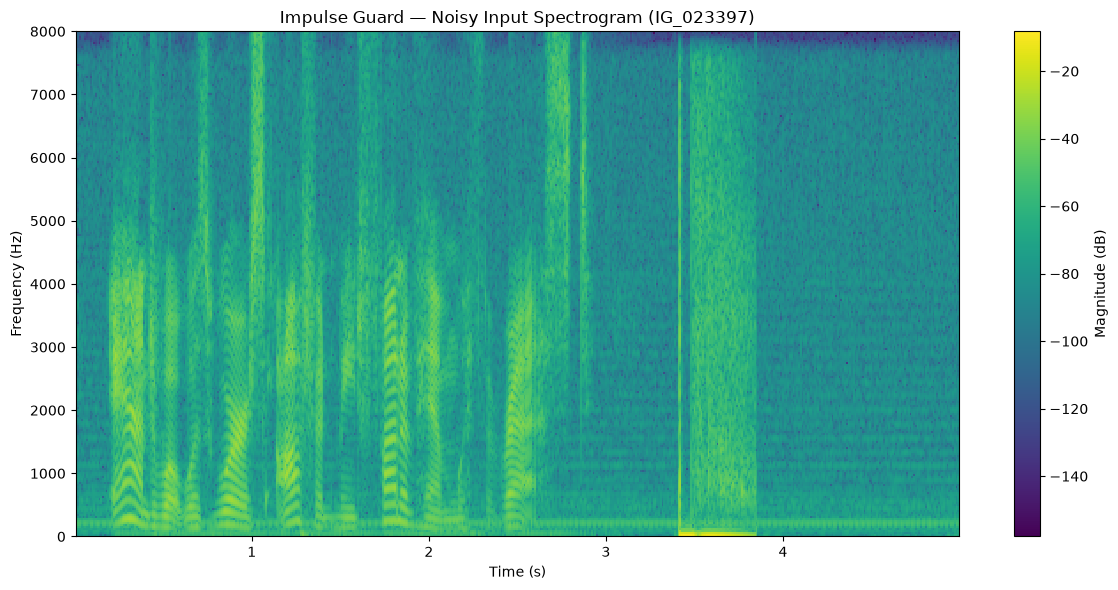

In [22]:
plot_spectrogram(
    noisy,
    sr,
    f"Impulse Guard — Noisy Input Spectrogram ({SAMPLE_ID})"
)

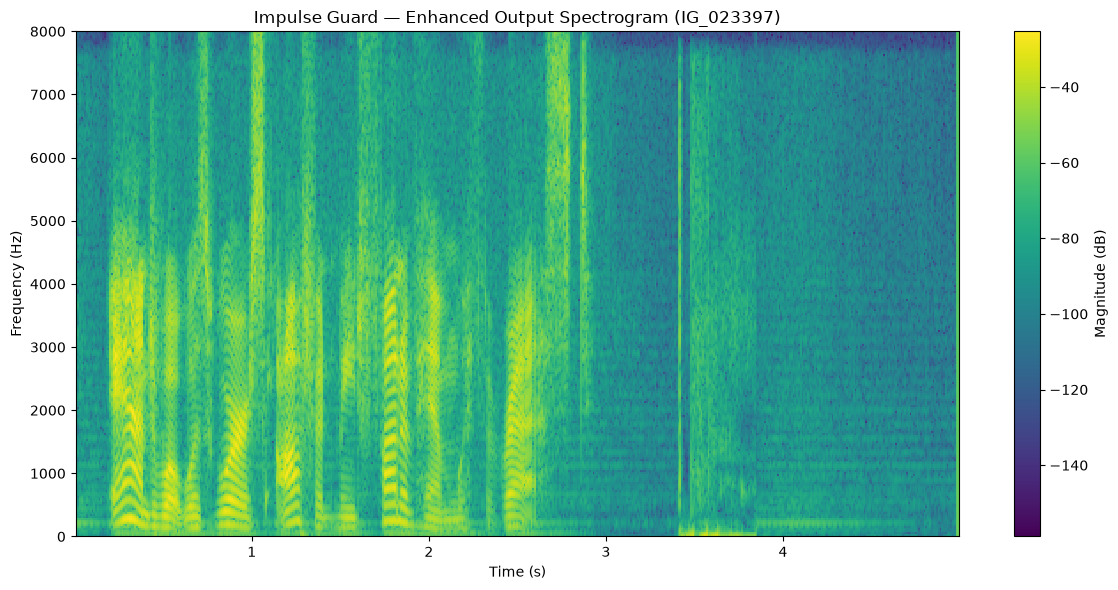

In [23]:
plot_spectrogram(
    enhanced,
    sr,
    f"Impulse Guard — Enhanced Output Spectrogram ({SAMPLE_ID})"
)

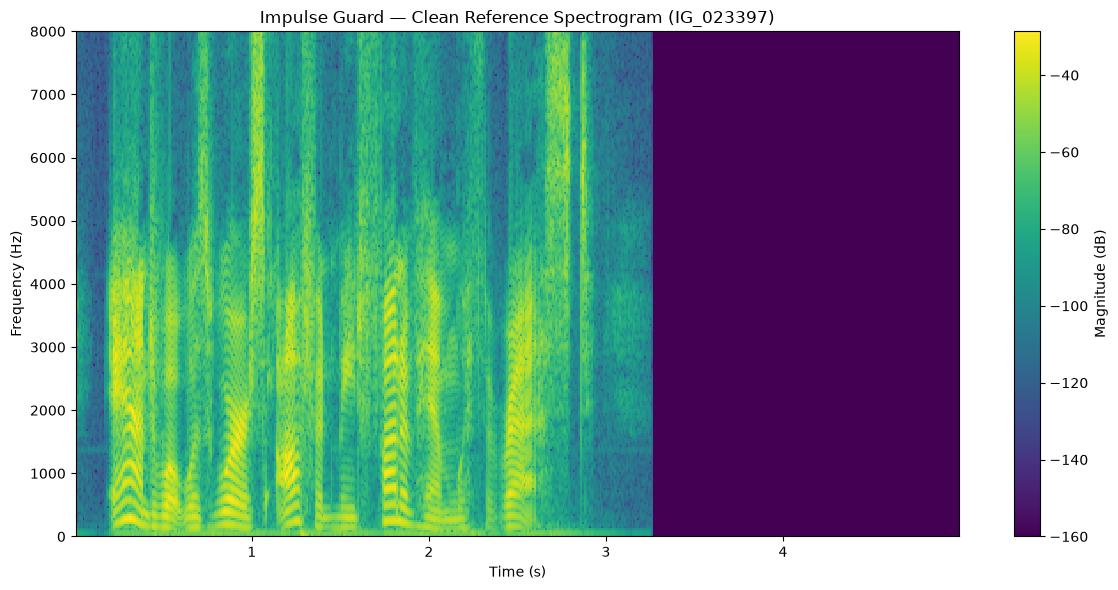

In [24]:
plot_spectrogram(
    clean,
    sr,
    f"Impulse Guard — Clean Reference Spectrogram ({SAMPLE_ID})"
)

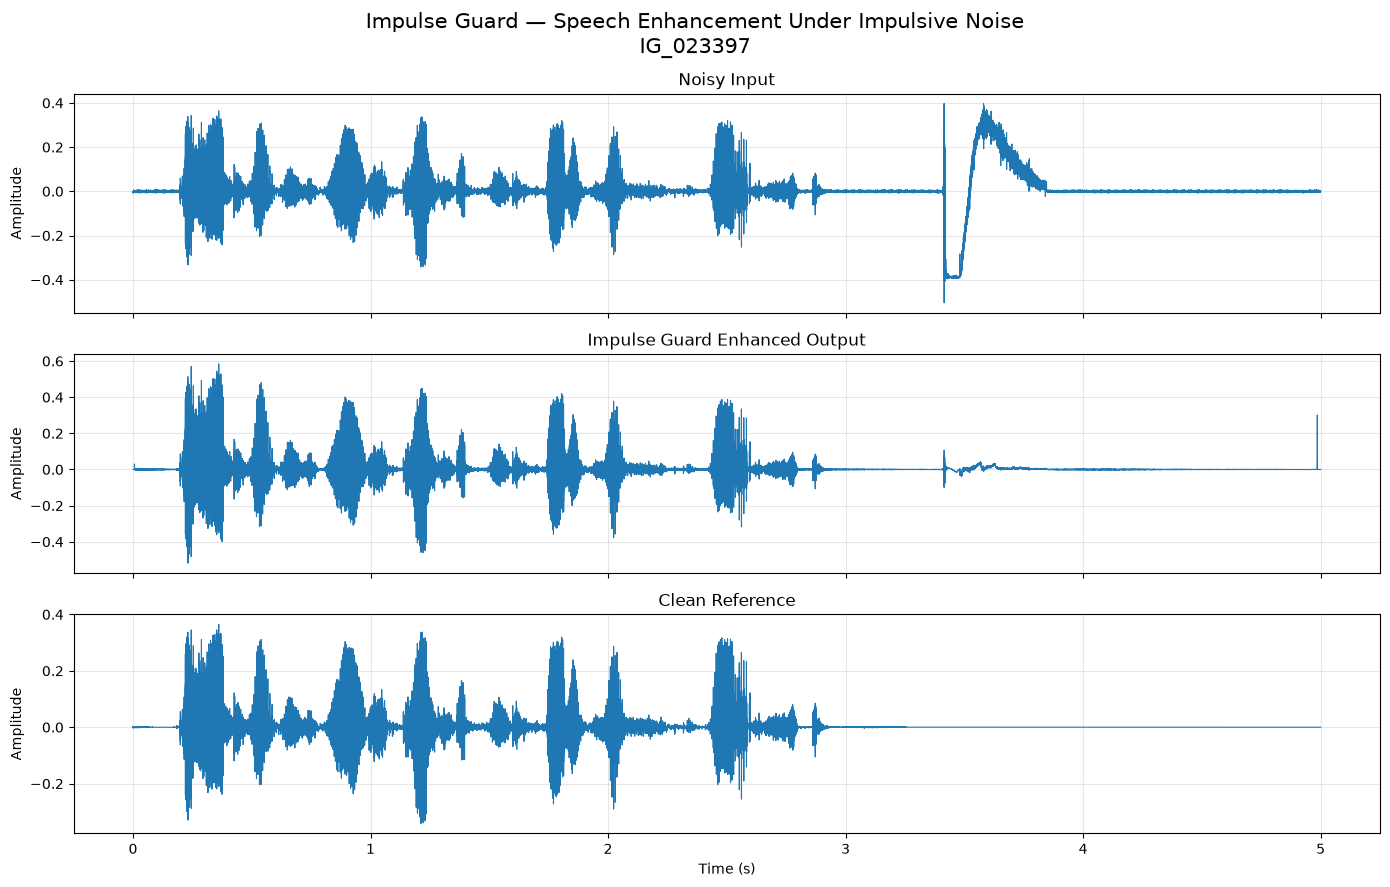

In [25]:
time = np.arange(len(noisy)) / sr

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(time, noisy, linewidth=0.8)
axes[0].set_title("Noisy Input")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

axes[1].plot(time, enhanced, linewidth=0.8)
axes[1].set_title("Impulse Guard Enhanced Output")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True, alpha=0.3)

axes[2].plot(time, clean, linewidth=0.8)
axes[2].set_title("Clean Reference")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Amplitude")
axes[2].grid(True, alpha=0.3)

fig.suptitle(
    f"Impulse Guard — Speech Enhancement Under Impulsive Noise\n{SAMPLE_ID}",
    fontsize=15
)

plt.tight_layout()
plt.show()

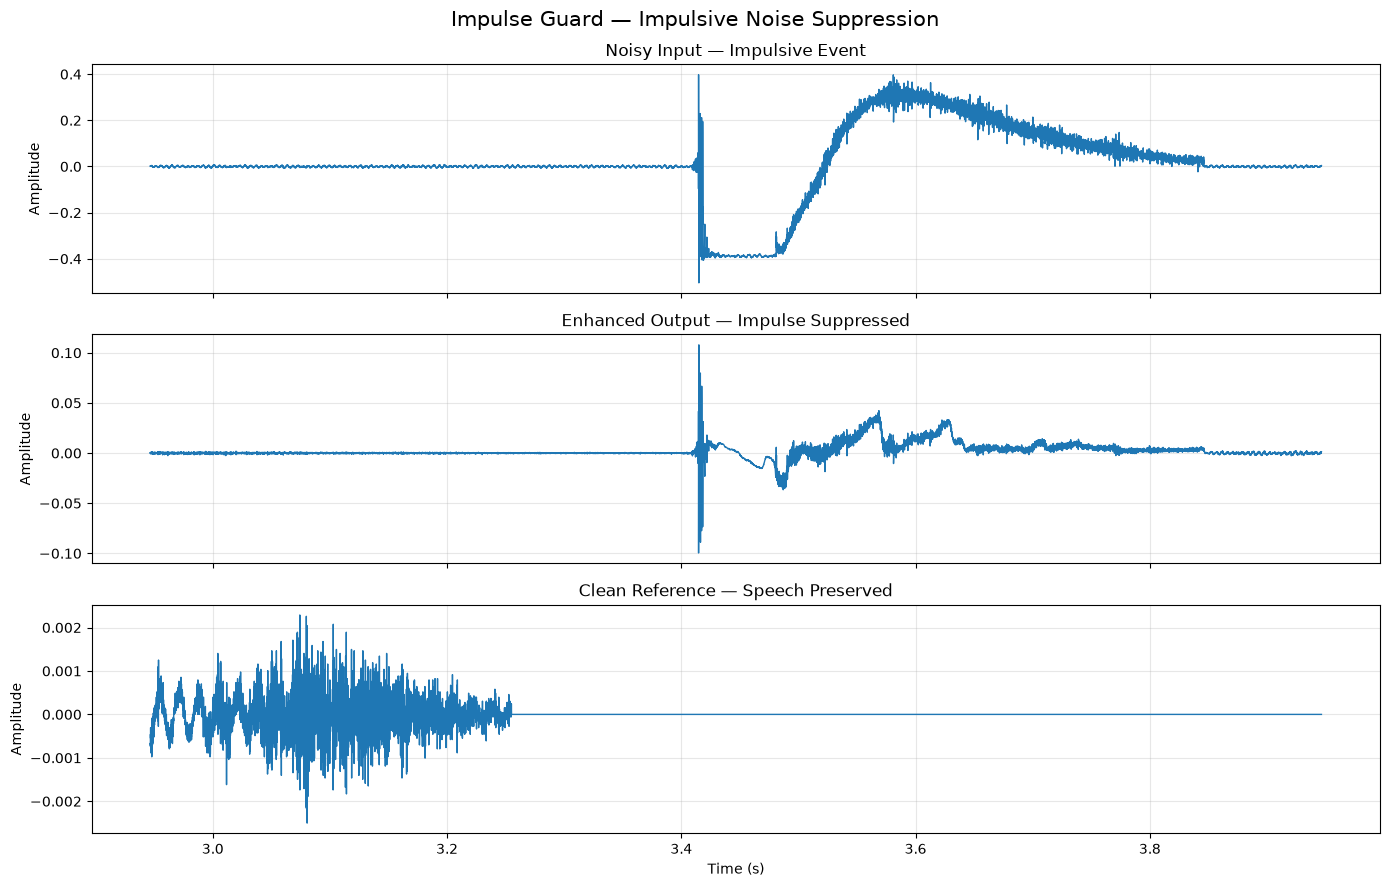

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(zoom_time, noisy[start:end], linewidth=1)
axes[0].set_title("Noisy Input — Impulsive Event")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

axes[1].plot(zoom_time, enhanced[start:end], linewidth=1)
axes[1].set_title("Enhanced Output — Impulse Suppressed")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True, alpha=0.3)

axes[2].plot(zoom_time, clean[start:end], linewidth=1)
axes[2].set_title("Clean Reference — Speech Preserved")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Amplitude")
axes[2].grid(True, alpha=0.3)

fig.suptitle(
    "Impulse Guard — Impulsive Noise Suppression",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [27]:
values = noisy_df["si_snr_improvement"].dropna()

print("Number of noisy samples:", len(values))
print(f"Mean:   {values.mean():.2f} dB")
print(f"Median: {values.median():.2f} dB")
print(f"Std:    {values.std():.2f} dB")
print(f"Min:    {values.min():.2f} dB")
print(f"Max:    {values.max():.2f} dB")

Number of noisy samples: 2687
Mean:   4.70 dB
Median: 4.59 dB
Std:    5.38 dB
Min:    -18.50 dB
Max:    22.83 dB


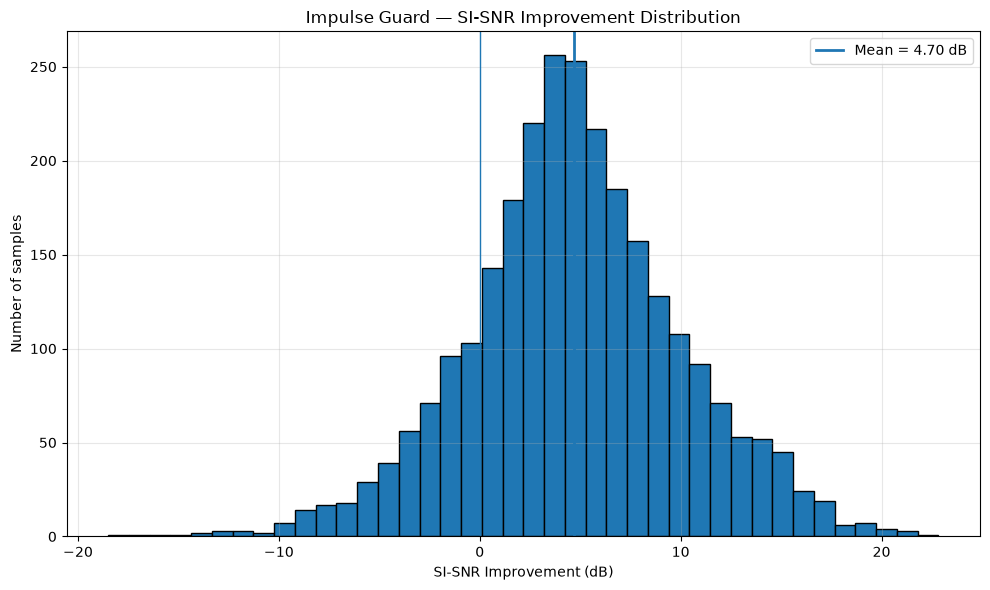

In [28]:
plt.figure(figsize=(10, 6))

plt.hist(
    values,
    bins=40,
    edgecolor="black"
)

plt.axvline(
    values.mean(),
    linewidth=2,
    label=f"Mean = {values.mean():.2f} dB"
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("SI-SNR Improvement (dB)")
plt.ylabel("Number of samples")
plt.title("Impulse Guard — SI-SNR Improvement Distribution")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
stoi_summary = (
    noisy_df
    .dropna(subset=["target_snr"])
    .groupby("target_snr")["stoi_improvement"]
    .mean()
    .sort_index()
)

print(stoi_summary)

target_snr
-5.0     0.019890
 0.0     0.029988
 5.0     0.027568
 10.0    0.015849
 15.0    0.011541
 20.0    0.005412
Name: stoi_improvement, dtype: float64


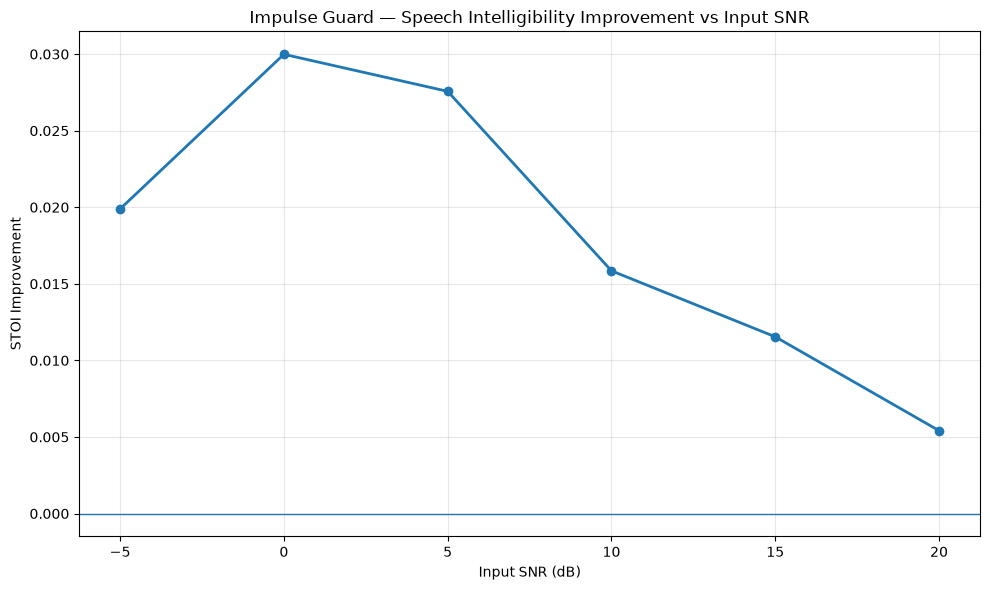

In [30]:
plt.figure(figsize=(10, 6))

plt.plot(
    stoi_summary.index,
    stoi_summary.values,
    marker="o",
    linewidth=2
)

plt.axhline(0, linewidth=1)

plt.xlabel("Input SNR (dB)")
plt.ylabel("STOI Improvement")
plt.title("Impulse Guard — Speech Intelligibility Improvement vs Input SNR")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# ==============================
# IMPULSE GUARD — KEY RESULTS
# ==============================

impulsive_df = noisy_df[noisy_df["is_impulsive"] == True]
non_impulsive_df = noisy_df[noisy_df["is_impulsive"] == False]

summary = {
    "Non-impulsive SI-SNRi (dB)": non_impulsive_df["si_snr_improvement"].mean(),
    "Impulsive SI-SNRi (dB)": impulsive_df["si_snr_improvement"].mean(),
    "Impulsive peak attenuation (dB)": impulsive_df["peak_attenuation_db_mean"].mean(),
    "Residual impulse energy ratio": impulsive_df["residual_energy_ratio_mean"].mean(),
    "IISRT (ms)": impulsive_df["iisrt_mean_ms"].mean(),
    "RSDD (ms)": impulsive_df["rsdd_mean_ms"].mean(),
    "Impulsive STOIi": impulsive_df["stoi_improvement"].mean(),
}

for metric, value in summary.items():
    print(f"{metric}: {value:.3f}")

Non-impulsive SI-SNRi (dB): 1.173
Impulsive SI-SNRi (dB): 6.757
Impulsive peak attenuation (dB): 12.131
Residual impulse energy ratio: 0.099
IISRT (ms): 233.450
RSDD (ms): 457.083
Impulsive STOIi: 0.015


In [32]:
residual = impulsive_df["residual_energy_ratio_mean"].mean()

energy_reduction = (1 - residual) * 100

print(f"Average measured impulse-energy reduction: {energy_reduction:.1f}%")

Average measured impulse-energy reduction: 90.1%


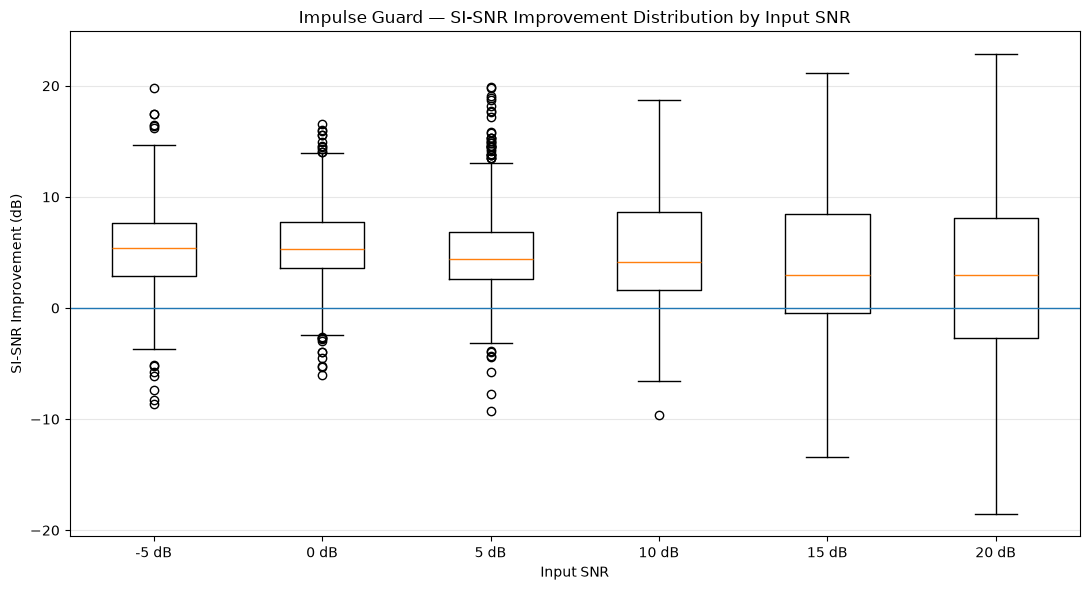

In [35]:
snr_values = sorted(
    noisy_df["target_snr"].dropna().unique()
)

data = [
    noisy_df[
        noisy_df["target_snr"] == snr
    ]["si_snr_improvement"].dropna()
    for snr in snr_values
]

plt.figure(figsize=(11, 6))

plt.boxplot(
    data,
    tick_labels=[f"{snr:.0f} dB" for snr in snr_values]
)

plt.axhline(0, linewidth=1)

plt.xlabel("Input SNR")
plt.ylabel("SI-SNR Improvement (dB)")
plt.title("Impulse Guard — SI-SNR Improvement Distribution by Input SNR")
plt.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

IMPULSE GUARD — PPT DATA ANALYSIS
Total evaluated samples : 3000
Noisy samples           : 2687
Clean control samples   : 313

[1/5] Generating SI-SNR vs Input SNR...

SI-SNR improvement by input SNR:
target_snr
-5.0     5.297639
 0.0     5.673030
 5.0     5.221139
 10.0    5.228950
 15.0    3.959333
 20.0    2.905438
Name: si_snr_improvement, dtype: float64


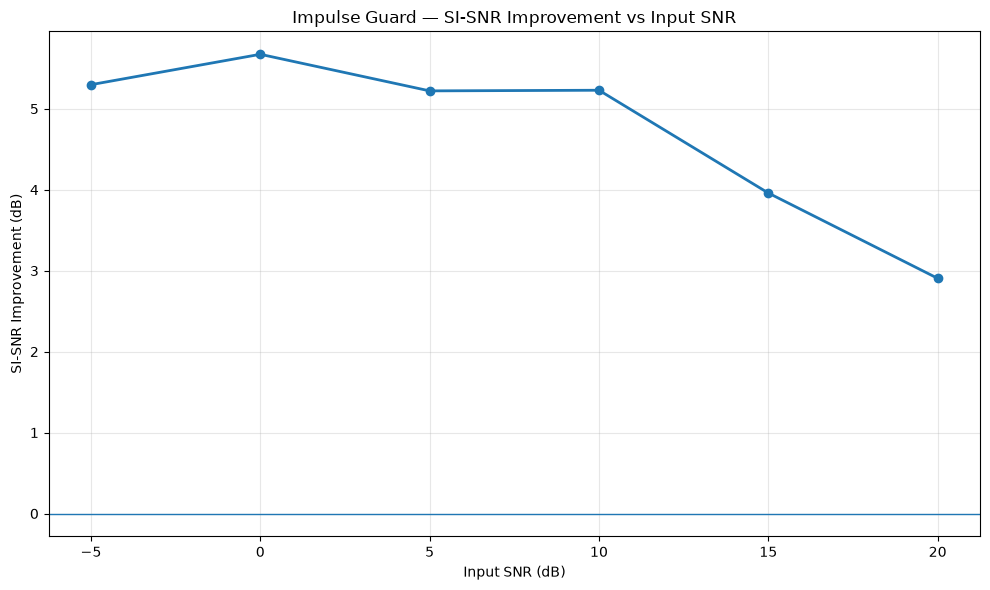


[2/5] Generating impulsive vs non-impulsive comparison...
Non-impulsive SI-SNRi : 1.17 dB
Impulsive SI-SNRi     : 6.76 dB


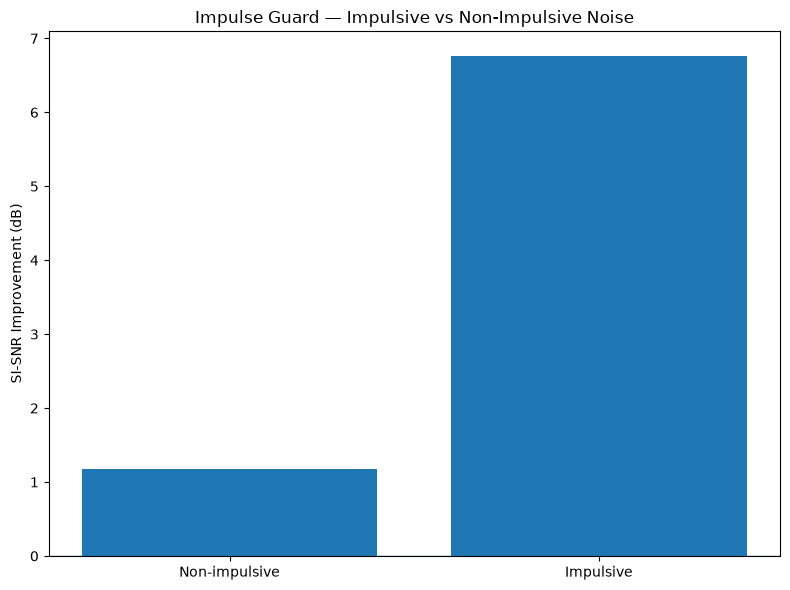


[3/5] Generating impulse attenuation graph...
Peak attenuation      : 12.13 dB
Residual energy ratio : 0.10
Energy reduction      : 90.1%
IISRT                 : 233.45 ms
RSDD                  : 457.08 ms


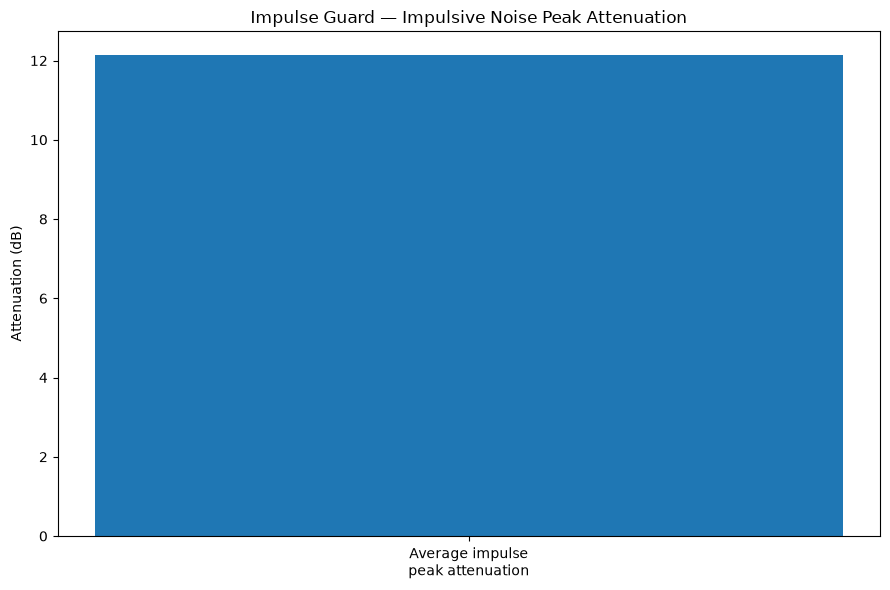


[4/5] Generating SI-SNR box plot...


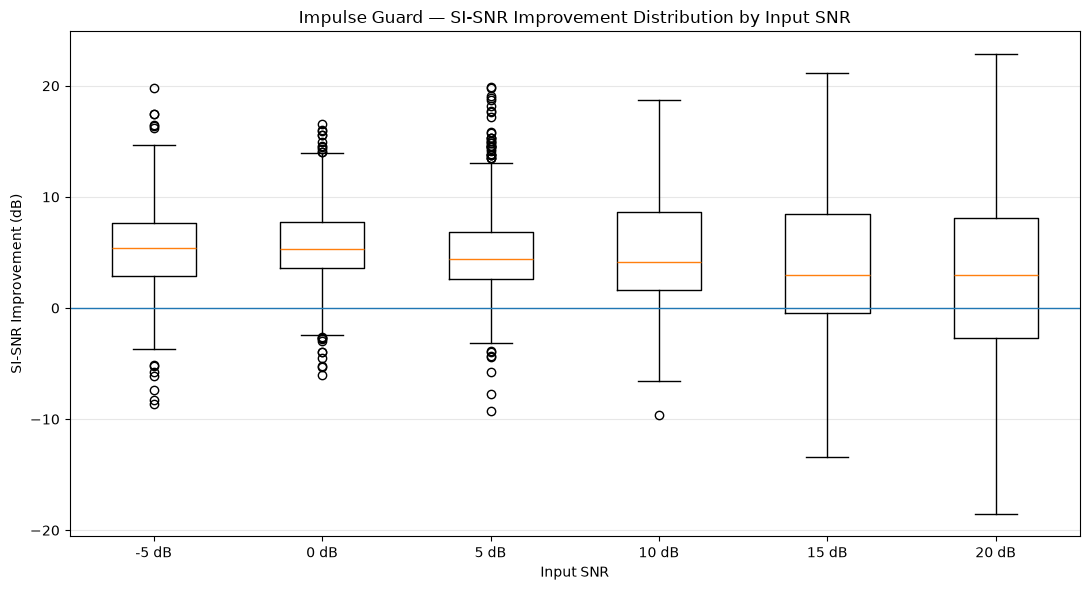


[5/5] Generating waveform comparison...

Selected representative sample: IG_023397
Noise condition: drone+impulsive
Input SNR: 20.0 dB
SI-SNR improvement: 22.83 dB
Strongest transient: 3.447 seconds


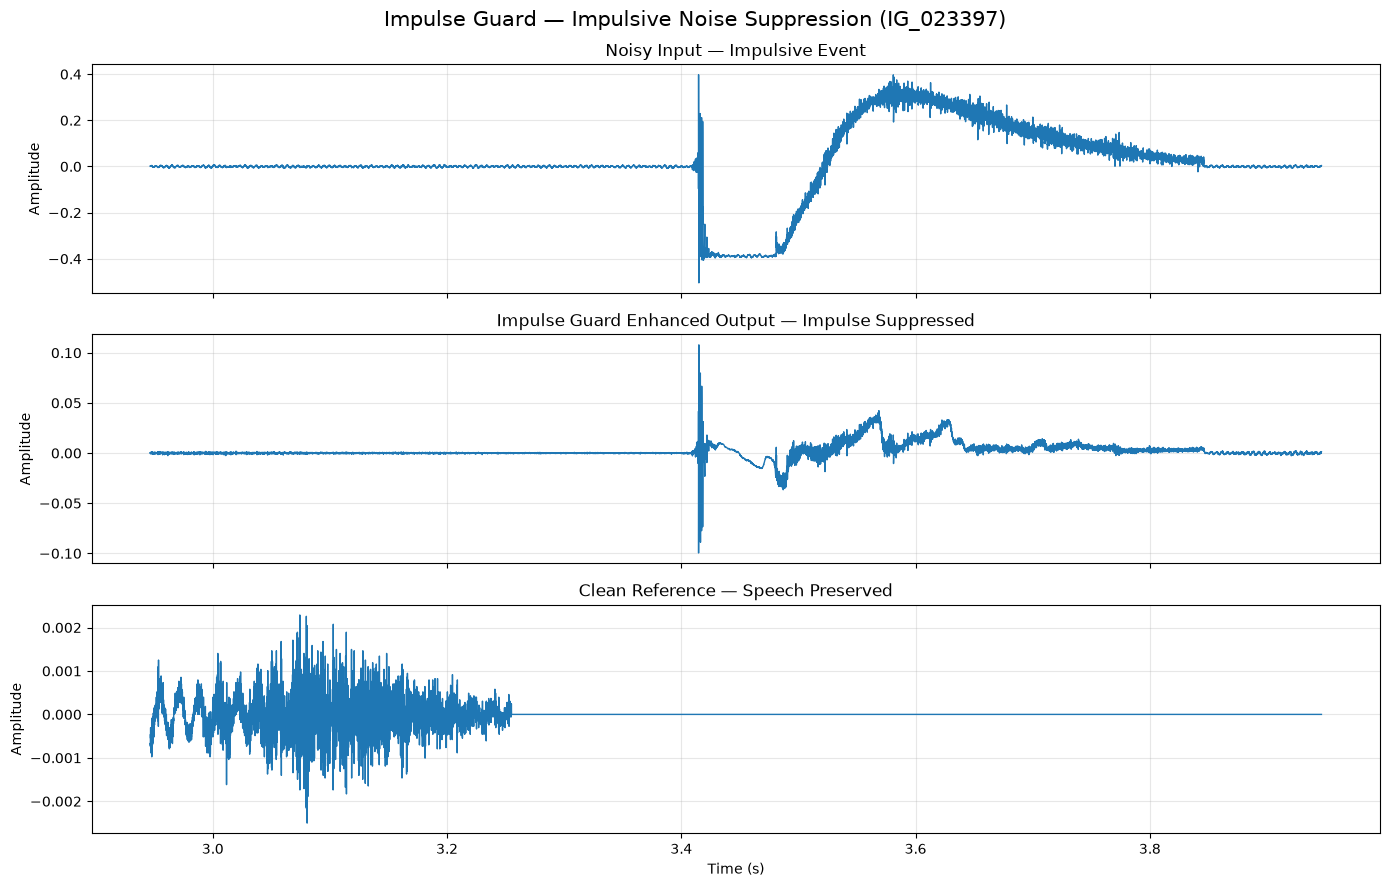


IMPULSE GUARD — FINAL ANALYSIS SUMMARY
Test samples evaluated       : 3000
Impulsive samples            : 1695

Non-impulsive SI-SNRi        : 1.17 dB
Impulsive SI-SNRi            : 6.76 dB
Peak attenuation             : 12.13 dB
Residual impulse energy      : 0.10
Impulse energy reduction     : 90.1%
IISRT                        : 233.45 ms
RSDD                         : 457.08 ms

Representative sample        : IG_023397
Representative input SNR     : 20.0 dB
Representative SI-SNRi       : 22.83 dB

Figures saved in: ../results/figures


In [36]:
# ============================================================
# IMPULSE GUARD — COMPLETE PPT DATA ANALYSIS
# Generates all major evaluation figures sequentially
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
from scipy import signal

# ------------------------------------------------------------
# 0. Setup
# ------------------------------------------------------------

FIG_DIR = "../results/figures"
os.makedirs(FIG_DIR, exist_ok=True)

print("=" * 60)
print("IMPULSE GUARD — PPT DATA ANALYSIS")
print("=" * 60)

# Make sure dataframe exists
if "df" not in globals():
    RESULTS_CSV = "../results/metrics/evaluation_results.csv"
    df = pd.read_csv(RESULTS_CSV)

# Separate clean control and noisy samples
noisy_df = df[df["noise_category"] != "clean"].copy()
clean_df = df[df["noise_category"] == "clean"].copy()

print(f"Total evaluated samples : {len(df)}")
print(f"Noisy samples           : {len(noisy_df)}")
print(f"Clean control samples   : {len(clean_df)}")


# ============================================================
# 1. SI-SNR IMPROVEMENT VS INPUT SNR
# ============================================================

print("\n[1/5] Generating SI-SNR vs Input SNR...")

snr_summary = (
    noisy_df
    .dropna(subset=["target_snr"])
    .groupby("target_snr")["si_snr_improvement"]
    .mean()
    .sort_index()
)

print("\nSI-SNR improvement by input SNR:")
print(snr_summary)

plt.figure(figsize=(10, 6))

plt.plot(
    snr_summary.index,
    snr_summary.values,
    marker="o",
    linewidth=2
)

plt.axhline(0, linewidth=1)

plt.xlabel("Input SNR (dB)")
plt.ylabel("SI-SNR Improvement (dB)")
plt.title("Impulse Guard — SI-SNR Improvement vs Input SNR")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{FIG_DIR}/01_si_snr_vs_snr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 2. IMPULSIVE VS NON-IMPULSIVE
# ============================================================

print("\n[2/5] Generating impulsive vs non-impulsive comparison...")

impulsive_df = noisy_df[
    noisy_df["is_impulsive"] == True
].copy()

non_impulsive_df = noisy_df[
    noisy_df["is_impulsive"] == False
].copy()

non_impulsive = non_impulsive_df[
    "si_snr_improvement"
].mean()

impulsive = impulsive_df[
    "si_snr_improvement"
].mean()

print(f"Non-impulsive SI-SNRi : {non_impulsive:.2f} dB")
print(f"Impulsive SI-SNRi     : {impulsive:.2f} dB")

plt.figure(figsize=(8, 6))

plt.bar(
    ["Non-impulsive", "Impulsive"],
    [non_impulsive, impulsive]
)

plt.axhline(0, linewidth=1)

plt.ylabel("SI-SNR Improvement (dB)")
plt.title("Impulse Guard — Impulsive vs Non-Impulsive Noise")

plt.tight_layout()

plt.savefig(
    f"{FIG_DIR}/02_impulsive_vs_nonimpulsive.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 3. IMPULSE PEAK ATTENUATION
# ============================================================

print("\n[3/5] Generating impulse attenuation graph...")

peak_attenuation = impulsive_df[
    "peak_attenuation_db_mean"
].mean()

residual_energy = impulsive_df[
    "residual_energy_ratio_mean"
].mean()

energy_reduction = (1 - residual_energy) * 100

iisrt = impulsive_df[
    "iisrt_mean_ms"
].mean()

rsdd = impulsive_df[
    "rsdd_mean_ms"
].mean()

print(f"Peak attenuation      : {peak_attenuation:.2f} dB")
print(f"Residual energy ratio : {residual_energy:.2f}")
print(f"Energy reduction      : {energy_reduction:.1f}%")
print(f"IISRT                 : {iisrt:.2f} ms")
print(f"RSDD                  : {rsdd:.2f} ms")

plt.figure(figsize=(9, 6))

plt.bar(
    ["Average impulse\npeak attenuation"],
    [peak_attenuation]
)

plt.ylabel("Attenuation (dB)")
plt.title("Impulse Guard — Impulsive Noise Peak Attenuation")

plt.tight_layout()

plt.savefig(
    f"{FIG_DIR}/03_impulse_peak_attenuation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 4. SI-SNR DISTRIBUTION BY INPUT SNR
# ============================================================

print("\n[4/5] Generating SI-SNR box plot...")

snr_values = sorted(
    noisy_df["target_snr"].dropna().unique()
)

box_data = []

for snr in snr_values:

    values = noisy_df[
        noisy_df["target_snr"] == snr
    ]["si_snr_improvement"].dropna()

    box_data.append(values)

plt.figure(figsize=(11, 6))

plt.boxplot(
    box_data,
    tick_labels=[
        f"{snr:.0f} dB"
        for snr in snr_values
    ]
)

plt.axhline(0, linewidth=1)

plt.xlabel("Input SNR")
plt.ylabel("SI-SNR Improvement (dB)")
plt.title(
    "Impulse Guard — SI-SNR Improvement Distribution by Input SNR"
)

plt.grid(
    True,
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    f"{FIG_DIR}/04_si_snr_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 5. WAVEFORM — NOISY VS ENHANCED VS CLEAN
# ============================================================

print("\n[5/5] Generating waveform comparison...")

# Automatically select the best impulsive sample
best_sample = impulsive_df.sort_values(
    "si_snr_improvement",
    ascending=False
).iloc[0]

SAMPLE_ID = best_sample["sample_id"]

print(f"\nSelected representative sample: {SAMPLE_ID}")
print(f"Noise condition: {best_sample['noise_category']}")
print(f"Input SNR: {best_sample['target_snr']} dB")
print(
    f"SI-SNR improvement: "
    f"{best_sample['si_snr_improvement']:.2f} dB"
)

noisy_path = (
    f"../data/mixtures/test/noisy/{SAMPLE_ID}.wav"
)

clean_path = (
    f"../data/mixtures/test/clean/{SAMPLE_ID}.wav"
)

enhanced_path = (
    f"../data/enhanced/test/{SAMPLE_ID}.wav"
)

noisy, sr = sf.read(
    noisy_path,
    dtype="float32"
)

clean, _ = sf.read(
    clean_path,
    dtype="float32"
)

enhanced, _ = sf.read(
    enhanced_path,
    dtype="float32"
)

# Convert stereo to mono
if noisy.ndim > 1:
    noisy = noisy.mean(axis=1)

if clean.ndim > 1:
    clean = clean.mean(axis=1)

if enhanced.ndim > 1:
    enhanced = enhanced.mean(axis=1)

# ------------------------------------------------------------
# Find strongest transient automatically
# ------------------------------------------------------------

window_ms = 20
window = int(sr * window_ms / 1000)

energy = np.convolve(
    noisy ** 2,
    np.ones(window) / window,
    mode="same"
)

impulse_center = np.argmax(energy)

impulse_time = impulse_center / sr

print(
    f"Strongest transient: "
    f"{impulse_time:.3f} seconds"
)

# ------------------------------------------------------------
# Zoom around impulse
# ------------------------------------------------------------

zoom_seconds = 0.5

start = max(
    0,
    impulse_center - int(zoom_seconds * sr)
)

end = min(
    len(noisy),
    impulse_center + int(zoom_seconds * sr)
)

zoom_time = np.arange(
    start,
    end
) / sr

# ------------------------------------------------------------
# Plot waveform
# ------------------------------------------------------------

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 9),
    sharex=True
)

axes[0].plot(
    zoom_time,
    noisy[start:end],
    linewidth=1
)

axes[0].set_title(
    "Noisy Input — Impulsive Event"
)

axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)


axes[1].plot(
    zoom_time,
    enhanced[start:end],
    linewidth=1
)

axes[1].set_title(
    "Impulse Guard Enhanced Output — Impulse Suppressed"
)

axes[1].set_ylabel("Amplitude")
axes[1].grid(True, alpha=0.3)


axes[2].plot(
    zoom_time,
    clean[start:end],
    linewidth=1
)

axes[2].set_title(
    "Clean Reference — Speech Preserved"
)

axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Amplitude")
axes[2].grid(True, alpha=0.3)


fig.suptitle(
    f"Impulse Guard — Impulsive Noise Suppression ({SAMPLE_ID})",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    f"{FIG_DIR}/05_impulse_waveform_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FINAL RESULTS SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("IMPULSE GUARD — FINAL ANALYSIS SUMMARY")
print("=" * 60)

print(f"Test samples evaluated       : {len(df)}")
print(f"Impulsive samples            : {len(impulsive_df)}")
print()
print(f"Non-impulsive SI-SNRi        : {non_impulsive:.2f} dB")
print(f"Impulsive SI-SNRi            : {impulsive:.2f} dB")
print(f"Peak attenuation             : {peak_attenuation:.2f} dB")
print(f"Residual impulse energy      : {residual_energy:.2f}")
print(f"Impulse energy reduction     : {energy_reduction:.1f}%")
print(f"IISRT                        : {iisrt:.2f} ms")
print(f"RSDD                         : {rsdd:.2f} ms")
print()
print(f"Representative sample        : {SAMPLE_ID}")
print(f"Representative input SNR     : {best_sample['target_snr']} dB")
print(f"Representative SI-SNRi       : {best_sample['si_snr_improvement']:.2f} dB")
print()
print(f"Figures saved in: {FIG_DIR}")
print("=" * 60)